In [1]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding, TSNE, MDS, Isomap
import deep_sdf.workspace as ws
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
import time

In [ ]:
# 1. Load the latent vectors from your trained model
experiment_dir = 'examples/ADNI_1_LR_No_MCI/minimal_eikonal'
checkpoint = 'latest'

# Load latent vectors
latent_vectors = ws.load_latent_vectors(experiment_dir, checkpoint)
X = latent_vectors.cpu().numpy()

print(f'Loaded latent vectors with shape: {X.shape}')


Loaded latent vectors with shape: (696, 256)


In [22]:
# 2. Load the filenames of the meshes and labels
import json

with open(os.path.join(experiment_dir, 'specs.json'), 'r') as f:
    specs = json.load(f)

mesh_root = specs.get('DataSourceMesh', specs['DataSource'])
train_split_file = specs.get('TrainSplit')
test_split_file = specs.get('TestSplit')
labels_path = os.path.join(mesh_root, 'labels.pt')

def load_split(path):
    if not path:
        return []
    with open(path, 'r') as f:
        return json.load(f)

train_split = load_split(train_split_file)
test_split = load_split(test_split_file)

# Combine train + test (unique), but fall back if sizes mismatch latent vectors
split_list = []
seen = set()
for name in train_split + test_split:
    if name not in seen:
        split_list.append(name)
        seen.add(name)

valid_filenames = split_list
if X.shape[0] != len(valid_filenames):
    if len(train_split) == X.shape[0]:
        print('Latent count matches train split; using train split only.')
        valid_filenames = train_split
    else:
        print('Warning: latent count does not match split sizes.')

print(f'Train split: {len(train_split)}')
print(f'Test split: {len(test_split)}')
print(f'Using {len(valid_filenames)} filenames for label matching')

mesh_params = []
if os.path.exists(labels_path):
    print(f'Loading labels from {labels_path}')
    all_labels = torch.load(labels_path, map_location='cpu')

    for filename in valid_filenames:
        base_name = os.path.splitext(os.path.basename(filename))[0]
        params = {
            'diagnosis': -1,
            'age': float('nan'),
            'sex': -1,
            'volume': float('nan'),
        }
        if base_name in all_labels:
            label = all_labels[base_name]
            params['diagnosis'] = int(label[0].item())
            params['age'] = float(label[1].item())
            params['sex'] = int(label[2].item())
            params['volume'] = float(label[3].item())
        else:
            print(f'Warning: No label found for {base_name}')
        mesh_params.append(params)
else:
    print(f'labels.pt not found at {labels_path}')


Latent count matches train split; using train split only.
Train split: 696
Test split: 77
Using 696 filenames for label matching
Loading labels from /home/jakaria/ADNI/ADNI_1/adni_processed/combined_hippocampus_correspondence/minimal_scaled_obj_files/labels.pt


In [23]:
# Extract parameters for visualization
diagnosis = np.array([p.get('diagnosis', -1) for p in mesh_params])
age = np.array([p.get('age', float('nan')) for p in mesh_params], dtype=float)
sex = np.array([p.get('sex', -1) for p in mesh_params])
volume = np.array([p.get('volume', float('nan')) for p in mesh_params], dtype=float)

# Create ground truth factors array for SAP calculation
ground_truth_factors = np.column_stack((diagnosis, age, sex, volume))
factor_names = ['diagnosis', 'age', 'sex', 'volume']


In [24]:
# AD prediction imports (independent cell)
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report


In [26]:
# Predict AD (diagnosis == 1) from 256D latent vectors using a small MLP
mask = diagnosis >= 0
X_valid = X[mask]
y = (diagnosis[mask] == 1).astype(np.int64)

if X_valid.shape[1] != 256:
    print(f'Warning: expected 256D latent, got {X_valid.shape[1]}D')

if len(np.unique(y)) < 2:
    raise ValueError('Need at least two classes for AD prediction. Check labels.')

X_train, X_val, y_train, y_val = train_test_split(
    X_valid, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_ds = TensorDataset(
    torch.from_numpy(X_train).float(),
    torch.from_numpy(y_train)
)
val_ds = TensorDataset(
    torch.from_numpy(X_val).float(),
    torch.from_numpy(y_val)
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

model = nn.Sequential(
    nn.Linear(X_train.shape[1], 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 2),
).to(device)

class_counts = np.bincount(y_train)
class_weights = torch.tensor(
    len(y_train) / (2.0 * class_counts), dtype=torch.float32, device=device
)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(100):
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

model.eval()
with torch.no_grad():
    val_logits = []
    val_targets = []
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)
        val_logits.append(logits.cpu())
        val_targets.append(yb)

val_logits = torch.cat(val_logits, dim=0)
val_targets = torch.cat(val_targets, dim=0).numpy()
val_probs = torch.softmax(val_logits, dim=1)[:, 1].numpy()
val_preds = (val_probs >= 0.5).astype(np.int64)

acc = accuracy_score(val_targets, val_preds)
auc = roc_auc_score(val_targets, val_probs)
print(f'Validation accuracy: {acc:.3f}  AUROC: {auc:.3f}')
print(classification_report(val_targets, val_preds, digits=3))


Validation accuracy: 0.929  AUROC: 0.987
              precision    recall  f1-score   support

           0      0.926     0.949     0.938        79
           1      0.932     0.902     0.917        61

    accuracy                          0.929       140
   macro avg      0.929     0.926     0.927       140
weighted avg      0.929     0.929     0.928       140



In [7]:
# 3. Apply various dimensionality reduction and factor analysis techniques
plt.figure(figsize=(20, 16))
results = {}
transformed_latents = {}
distances_all = []


<Figure size 2000x1600 with 0 Axes>

In [8]:
# 3.1. PCA
print('Applying PCA...')
pca = PCA(n_components=4)
Y_pca = pca.fit_transform(X)
results['PCA'] = Y_pca
transformed_latents['PCA'] = Y_pca
print(f'PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}')

# check if volume is encoded as distance from the origin
center = np.mean(Y_pca, axis=0)
distances = np.sqrt(np.sum((Y_pca - center) ** 2, axis=1))
mask = np.isfinite(volume)
if np.any(mask):
    print(f'Correlation between distance from origin and volume: {np.corrcoef(distances[mask], volume[mask])[0, 1]:.4f}')
else:
    print('No finite volume values to compute distance correlation.')
distances_pca = distances
distances_all.append(distances)

# 3.2. HLLE+ICA
best_corr = -np.inf
best_Y_hlle_ica = None
best_params = None

# Loop over a range of n_neighbors and latent space dimensions
for n_neighbors in range(300, 320, 10):
    for n_components in [4]:
        try:
            hlle = LocallyLinearEmbedding(n_neighbors=n_neighbors,
                                           n_components=n_components,
                                           method='hessian',
                                           eigen_solver='dense')
            Z = hlle.fit_transform(X)

            ica = FastICA(n_components=n_components, random_state=42)
            Y_hlle_ica = ica.fit_transform(Z)

            correlations = []
            mask = diagnosis >= 0
            for comp in range(n_components):
                if np.any(mask):
                    corr = np.corrcoef(Y_hlle_ica[mask, comp], diagnosis[mask])[0, 1]
                else:
                    corr = float('nan')
                correlations.append(corr)
            print(correlations)

            best_component_idx = max(range(n_components), key=lambda i: abs(correlations[i]))
            best_component_corr = correlations[best_component_idx]

            print(f'n_neighbors: {n_neighbors}, n_components: {n_components}, '
                  f'best component correlation: {best_component_corr:.4f}')

            if abs(best_component_corr) > best_corr:
                best_corr = best_component_corr
                best_Y_hlle_ica = Y_hlle_ica
                best_params = (n_neighbors, n_components, best_component_idx)

        except Exception as e:
            print(f'Failed for n_neighbors: {n_neighbors}, n_components: {n_components} due to: {e}')

if best_Y_hlle_ica is not None:
    print('\nBest parameter set:')
    print(f'n_neighbors: {best_params[0]}, n_components: {best_params[1]}, best component: {best_params[2]} best correlation: {best_corr:.4f}')
    results['HLLE+ICA'] = best_Y_hlle_ica
    transformed_latents['HLLE+ICA'] = best_Y_hlle_ica
else:
    print('No valid HLLE+ICA transformation found.')


Applying PCA...
PCA explained variance ratio: 0.3753
Correlation between distance from origin and volume: -0.0633
[0.03442196231613396, -0.23676319479400285, -0.10884220097613195, -0.30492452984842633]
n_neighbors: 300, n_components: 4, best component correlation: -0.3049
[0.35219863348535374, -0.04898394800862242, 0.20561476011617394, -0.20820705699785463]
n_neighbors: 310, n_components: 4, best component correlation: 0.3522

Best parameter set:
n_neighbors: 310, n_components: 4, best component: 0 best correlation: 0.3522


In [9]:
# 3.3. NMF
print('Applying NMF...')
X_min = X.min()
if X_min < 0:
    X_offset = X - X_min
else:
    X_offset = X.copy()

best_corr_nmf = None
best_W_nmf = None
best_nmf_params = None

for n_components in [2, 3, 4]:
    try:
        nmf = NMF(n_components=n_components, random_state=42, max_iter=10000)
        W = nmf.fit_transform(X_offset)

        correlations = []
        mask = diagnosis >= 0
        for comp in range(n_components):
            if np.any(mask):
                corr = np.corrcoef(W[mask, comp], diagnosis[mask])[0, 1]
            else:
                corr = float('nan')
            correlations.append(corr)

        best_component_corr = max(correlations, key=abs)
        print(f'n_components: {n_components}, best component correlation (diagnosis): {best_component_corr:.4f}')

        if best_corr_nmf is None or abs(best_component_corr) > abs(best_corr_nmf):
            best_corr_nmf = best_component_corr
            best_W_nmf = W
            best_nmf_params = n_components

    except Exception as e:
        print(f'NMF failed for n_components: {n_components} due to: {e}')

if best_W_nmf is not None:
    results['NMF'] = best_W_nmf
    transformed_latents['NMF'] = best_W_nmf


Applying NMF...
n_components: 2, best component correlation (diagnosis): -0.3521
n_components: 3, best component correlation (diagnosis): 0.3341
n_components: 4, best component correlation (diagnosis): -0.2956


In [10]:
# 3.4. Factor Analysis
print('Applying Factor Analysis...')
fa = FactorAnalysis(n_components=4, random_state=42)
Y_fa = fa.fit_transform(X)
results['FA'] = Y_fa
transformed_latents['FA'] = Y_fa

center = np.mean(Y_fa, axis=0)
distances = np.sqrt(np.sum((Y_fa - center) ** 2, axis=1))
mask = np.isfinite(volume)
if np.any(mask):
    print(f'Correlation between distance from origin and volume: {np.corrcoef(distances[mask], volume[mask])[0, 1]:.4f}')
else:
    print('No finite volume values to compute distance correlation.')
distances_Y_fa = distances
distances_all.append(distances)


Applying Factor Analysis...
Correlation between distance from origin and volume: -0.0612


In [11]:
# 3.5. ICA
print('Applying ICA...')
ica = FastICA(n_components=4, random_state=42)
Y_ica = ica.fit_transform(X)
results['ICA'] = Y_ica
transformed_latents['ICA'] = Y_ica

center = np.mean(Y_ica, axis=0)
distances = np.sqrt(np.sum((Y_ica - center) ** 2, axis=1))
mask = np.isfinite(volume)
if np.any(mask):
    print(f'Correlation between distance from origin and volume: {np.corrcoef(distances[mask], volume[mask])[0, 1]:.4f}')
else:
    print('No finite volume values to compute distance correlation.')
distances_Y_ica = distances
distances_all.append(distances)


Applying ICA...
Correlation between distance from origin and volume: -0.0162


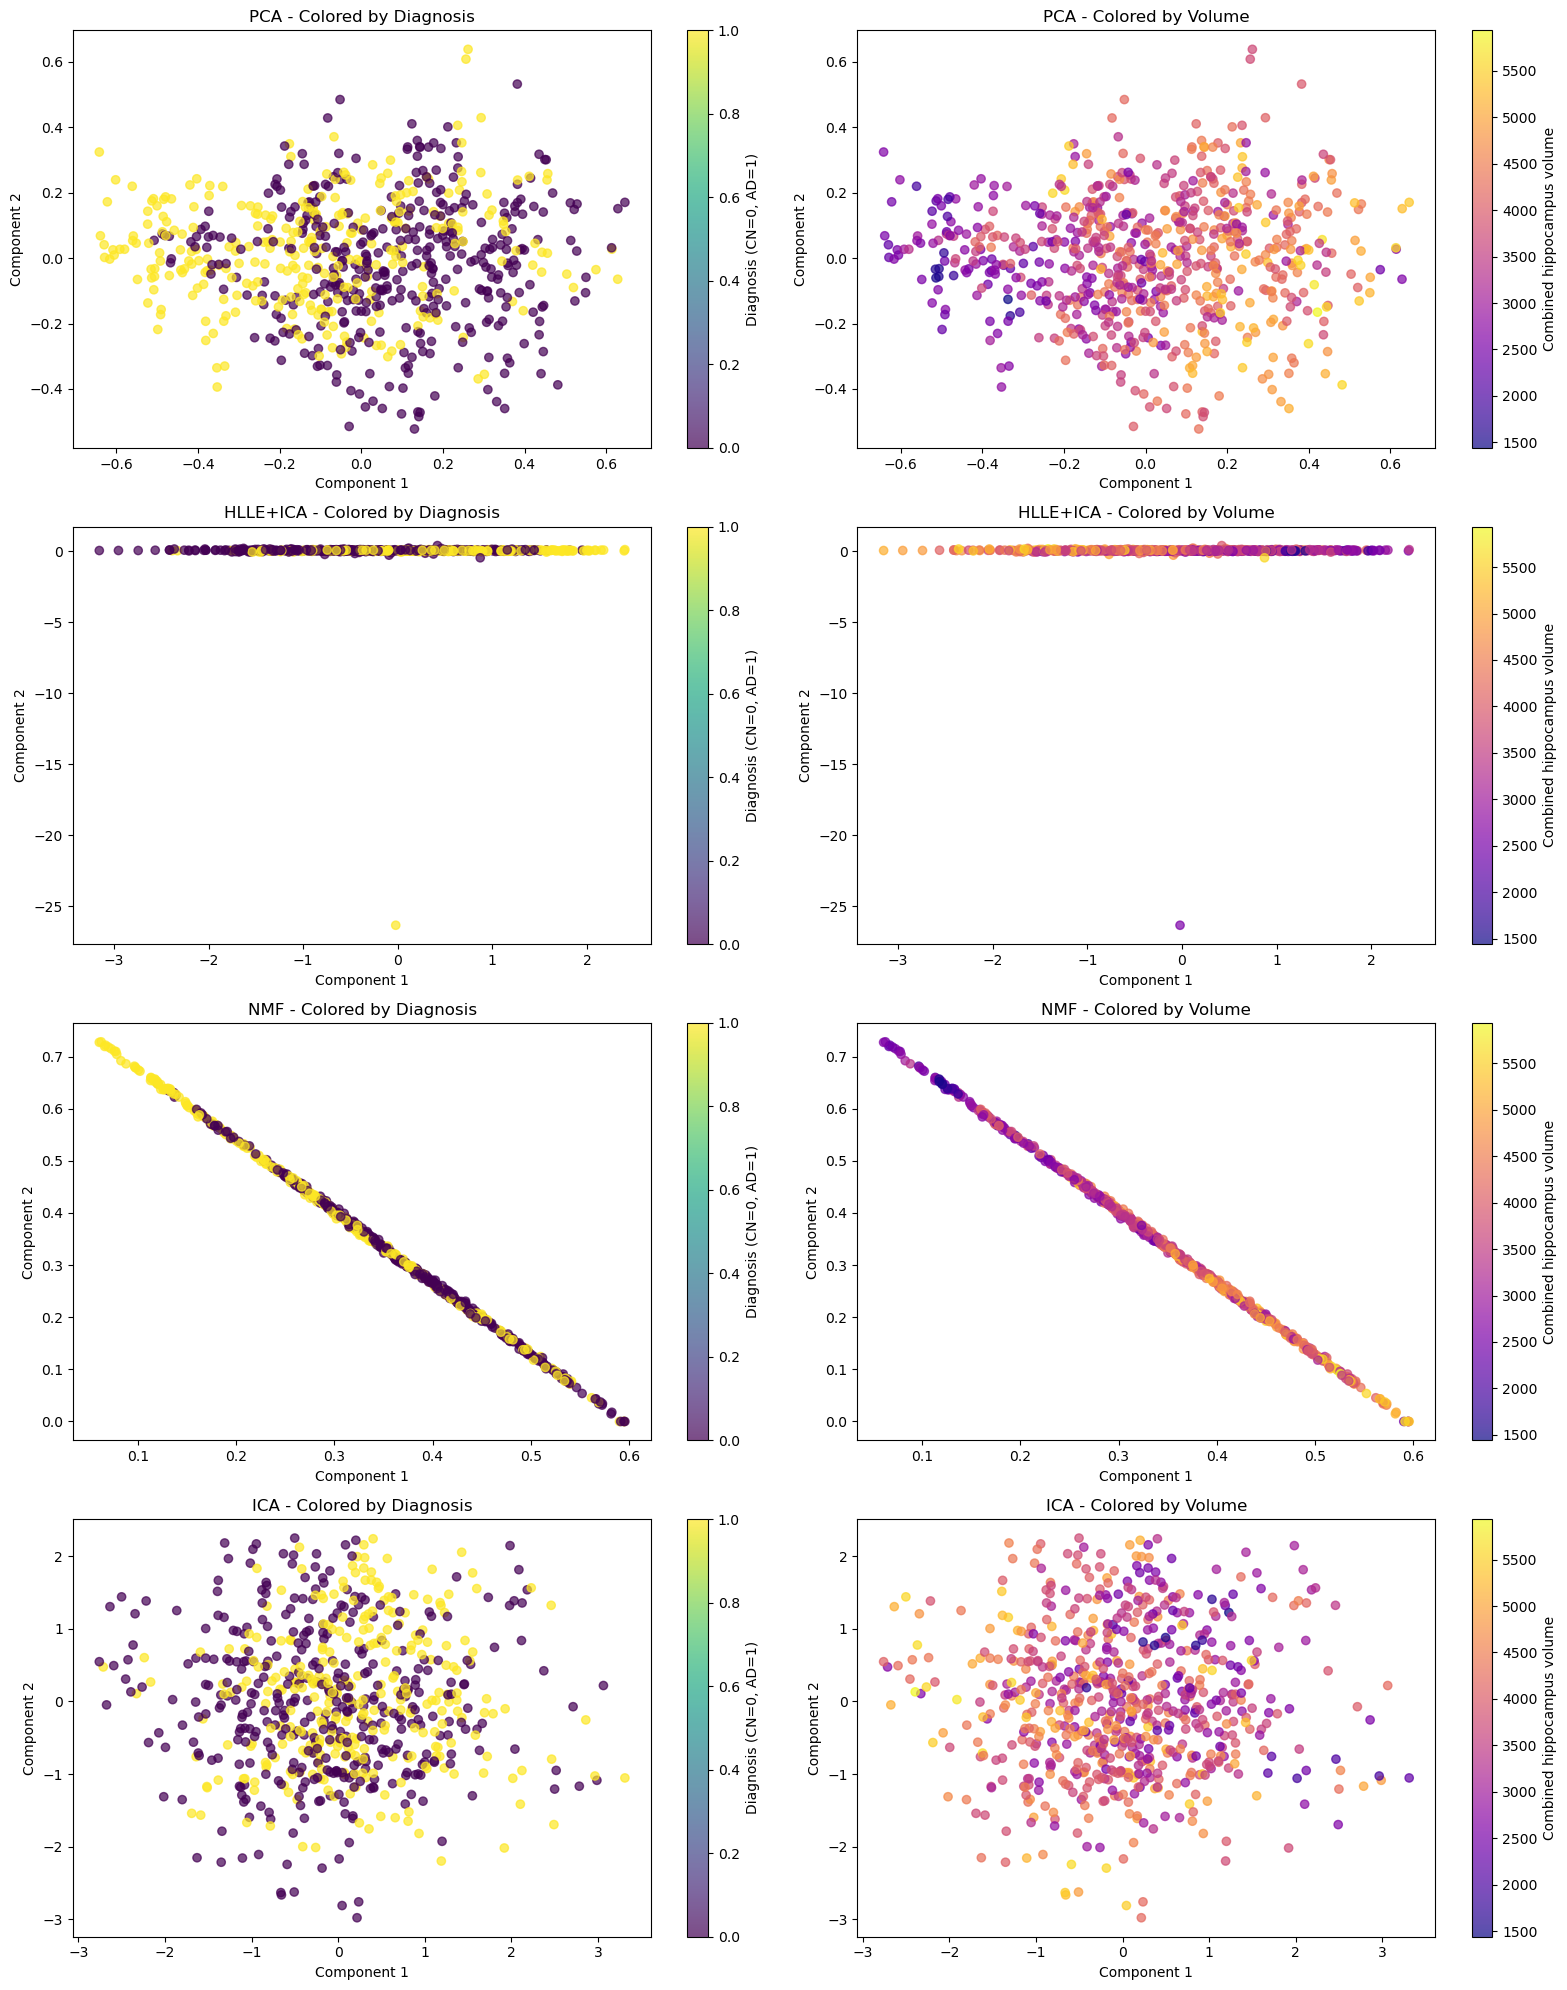

In [12]:
# 4. Visualize results
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

techniques = ['PCA', 'HLLE+ICA', 'NMF', 'ICA']
for i, technique in enumerate(techniques):
    if np.all(results[technique] == 0):
        continue

    scatter = axes[i, 0].scatter(results[technique][:, 0], results[technique][:, 1],
                                c=diagnosis, cmap='viridis', alpha=0.7)
    axes[i, 0].set_title(f'{technique} - Colored by Diagnosis')
    axes[i, 0].set_xlabel('Component 1')
    axes[i, 0].set_ylabel('Component 2')
    plt.colorbar(scatter, ax=axes[i, 0], label='Diagnosis (CN=0, AD=1)')

    mask = np.isfinite(volume)
    scatter = axes[i, 1].scatter(results[technique][mask, 0], results[technique][mask, 1],
                                c=volume[mask], cmap='plasma', alpha=0.7)
    axes[i, 1].set_title(f'{technique} - Colored by Volume')
    axes[i, 1].set_xlabel('Component 1')
    axes[i, 1].set_ylabel('Component 2')
    plt.colorbar(scatter, ax=axes[i, 1], label='Combined hippocampus volume')

plt.tight_layout()
plt.show()


In [13]:
# 5. Correlation Analysis
print('\nCorrelation Analysis:')
for technique in techniques:
    if np.all(results[technique] == 0):
        continue

    print(f'\n{technique} Analysis:')
    num_components = results[technique].shape[1]
    if np.any(diagnosis >= 0):
        mask = diagnosis >= 0
        for comp_idx in range(num_components):
            corr = np.corrcoef(results[technique][mask, comp_idx], diagnosis[mask])[0, 1]
            print(f'Component {comp_idx + 1} correlation with diagnosis: {corr:.4f}')
    if np.any(np.isfinite(age)):
        mask = np.isfinite(age)
        for comp_idx in range(num_components):
            corr = np.corrcoef(results[technique][mask, comp_idx], age[mask])[0, 1]
            print(f'Component {comp_idx + 1} correlation with age: {corr:.4f}')
    if np.any(sex >= 0):
        mask = sex >= 0
        for comp_idx in range(num_components):
            corr = np.corrcoef(results[technique][mask, comp_idx], sex[mask])[0, 1]
            print(f'Component {comp_idx + 1} correlation with sex: {corr:.4f}')
    if np.any(np.isfinite(volume)):
        mask = np.isfinite(volume)
        for comp_idx in range(num_components):
            corr = np.corrcoef(results[technique][mask, comp_idx], volume[mask])[0, 1]
            print(f'Component {comp_idx + 1} correlation with volume: {corr:.4f}')



Correlation Analysis:

PCA Analysis:
Component 1 correlation with diagnosis: -0.3508
Component 2 correlation with diagnosis: 0.0992
Component 3 correlation with diagnosis: -0.1392
Component 4 correlation with diagnosis: -0.3942
Component 1 correlation with age: 0.0523
Component 2 correlation with age: 0.0680
Component 3 correlation with age: 0.0287
Component 4 correlation with age: -0.3788
Component 1 correlation with sex: -0.2253
Component 2 correlation with sex: -0.2778
Component 3 correlation with sex: -0.2062
Component 4 correlation with sex: 0.0725
Component 1 correlation with volume: 0.5929
Component 2 correlation with volume: -0.0281
Component 3 correlation with volume: 0.1390
Component 4 correlation with volume: 0.5715

HLLE+ICA Analysis:
Component 1 correlation with diagnosis: 0.3522
Component 2 correlation with diagnosis: -0.0490
Component 3 correlation with diagnosis: 0.2056
Component 4 correlation with diagnosis: -0.2082
Component 1 correlation with age: -0.0074
Component 

In [14]:
from scipy.stats import kurtosis, skew
from sklearn.metrics import normalized_mutual_info_score

def evaluate_ica_quality(components):
    """Evaluate ICA component quality using statistical measures"""
    metrics = {}
    
    for i in range(components.shape[1]):
        comp = components[:, i]
        
        # Kurtosis (departure from Gaussianity)
        kurt = kurtosis(comp)
        
        # Skewness (asymmetry)
        skewness = skew(comp)
        
        # Negentropy approximation (measure of non-Gaussianity)
        # Using tanh approximation
        negentropy = np.mean(np.tanh(comp)**2) - (np.mean(np.tanh(comp)))**2
        
        metrics[f'component_{i}'] = {
            'kurtosis': kurt,
            'skewness': skewness,
            'negentropy': negentropy,
            'variance': np.var(comp)
        }
    
    return metrics

# Usage
for technique in techniques:
    if technique in results and not np.all(results[technique] == 0):
        quality = evaluate_ica_quality(results[technique])
        print(f"\n{technique} Quality Metrics:")
        for comp, metrics in quality.items():
            print(f"{comp}: Kurt={metrics['kurtosis']:.3f}, "
                  f"Skew={metrics['skewness']:.3f}, "
                  f"Negent={metrics['negentropy']:.3f}")


PCA Quality Metrics:
component_0: Kurt=-0.461, Skew=-0.169, Negent=0.065
component_1: Kurt=0.137, Skew=-0.133, Negent=0.031
component_2: Kurt=0.025, Skew=0.297, Negent=0.020
component_3: Kurt=-0.247, Skew=0.026, Negent=0.019

HLLE+ICA Quality Metrics:
component_0: Kurt=-0.349, Skew=-0.155, Negent=0.408
component_1: Kurt=687.469, Skew=-26.224, Negent=0.004
component_2: Kurt=37.436, Skew=1.105, Negent=0.298
component_3: Kurt=-0.265, Skew=0.261, Negent=0.412

NMF Quality Metrics:
component_0: Kurt=-0.489, Skew=-0.188, Negent=0.011
component_1: Kurt=-0.498, Skew=0.188, Negent=0.019

ICA Quality Metrics:
component_0: Kurt=0.380, Skew=0.146, Negent=0.376
component_1: Kurt=-0.341, Skew=0.025, Negent=0.406
component_2: Kurt=-0.614, Skew=-0.205, Negent=0.421
component_3: Kurt=-0.558, Skew=-0.083, Negent=0.428


Projecting individual latent vectors onto learned components...


Projection shapes:
PCA: (696, 4)
ICA: (696, 4)
HLLE+ICA: (696, 2)


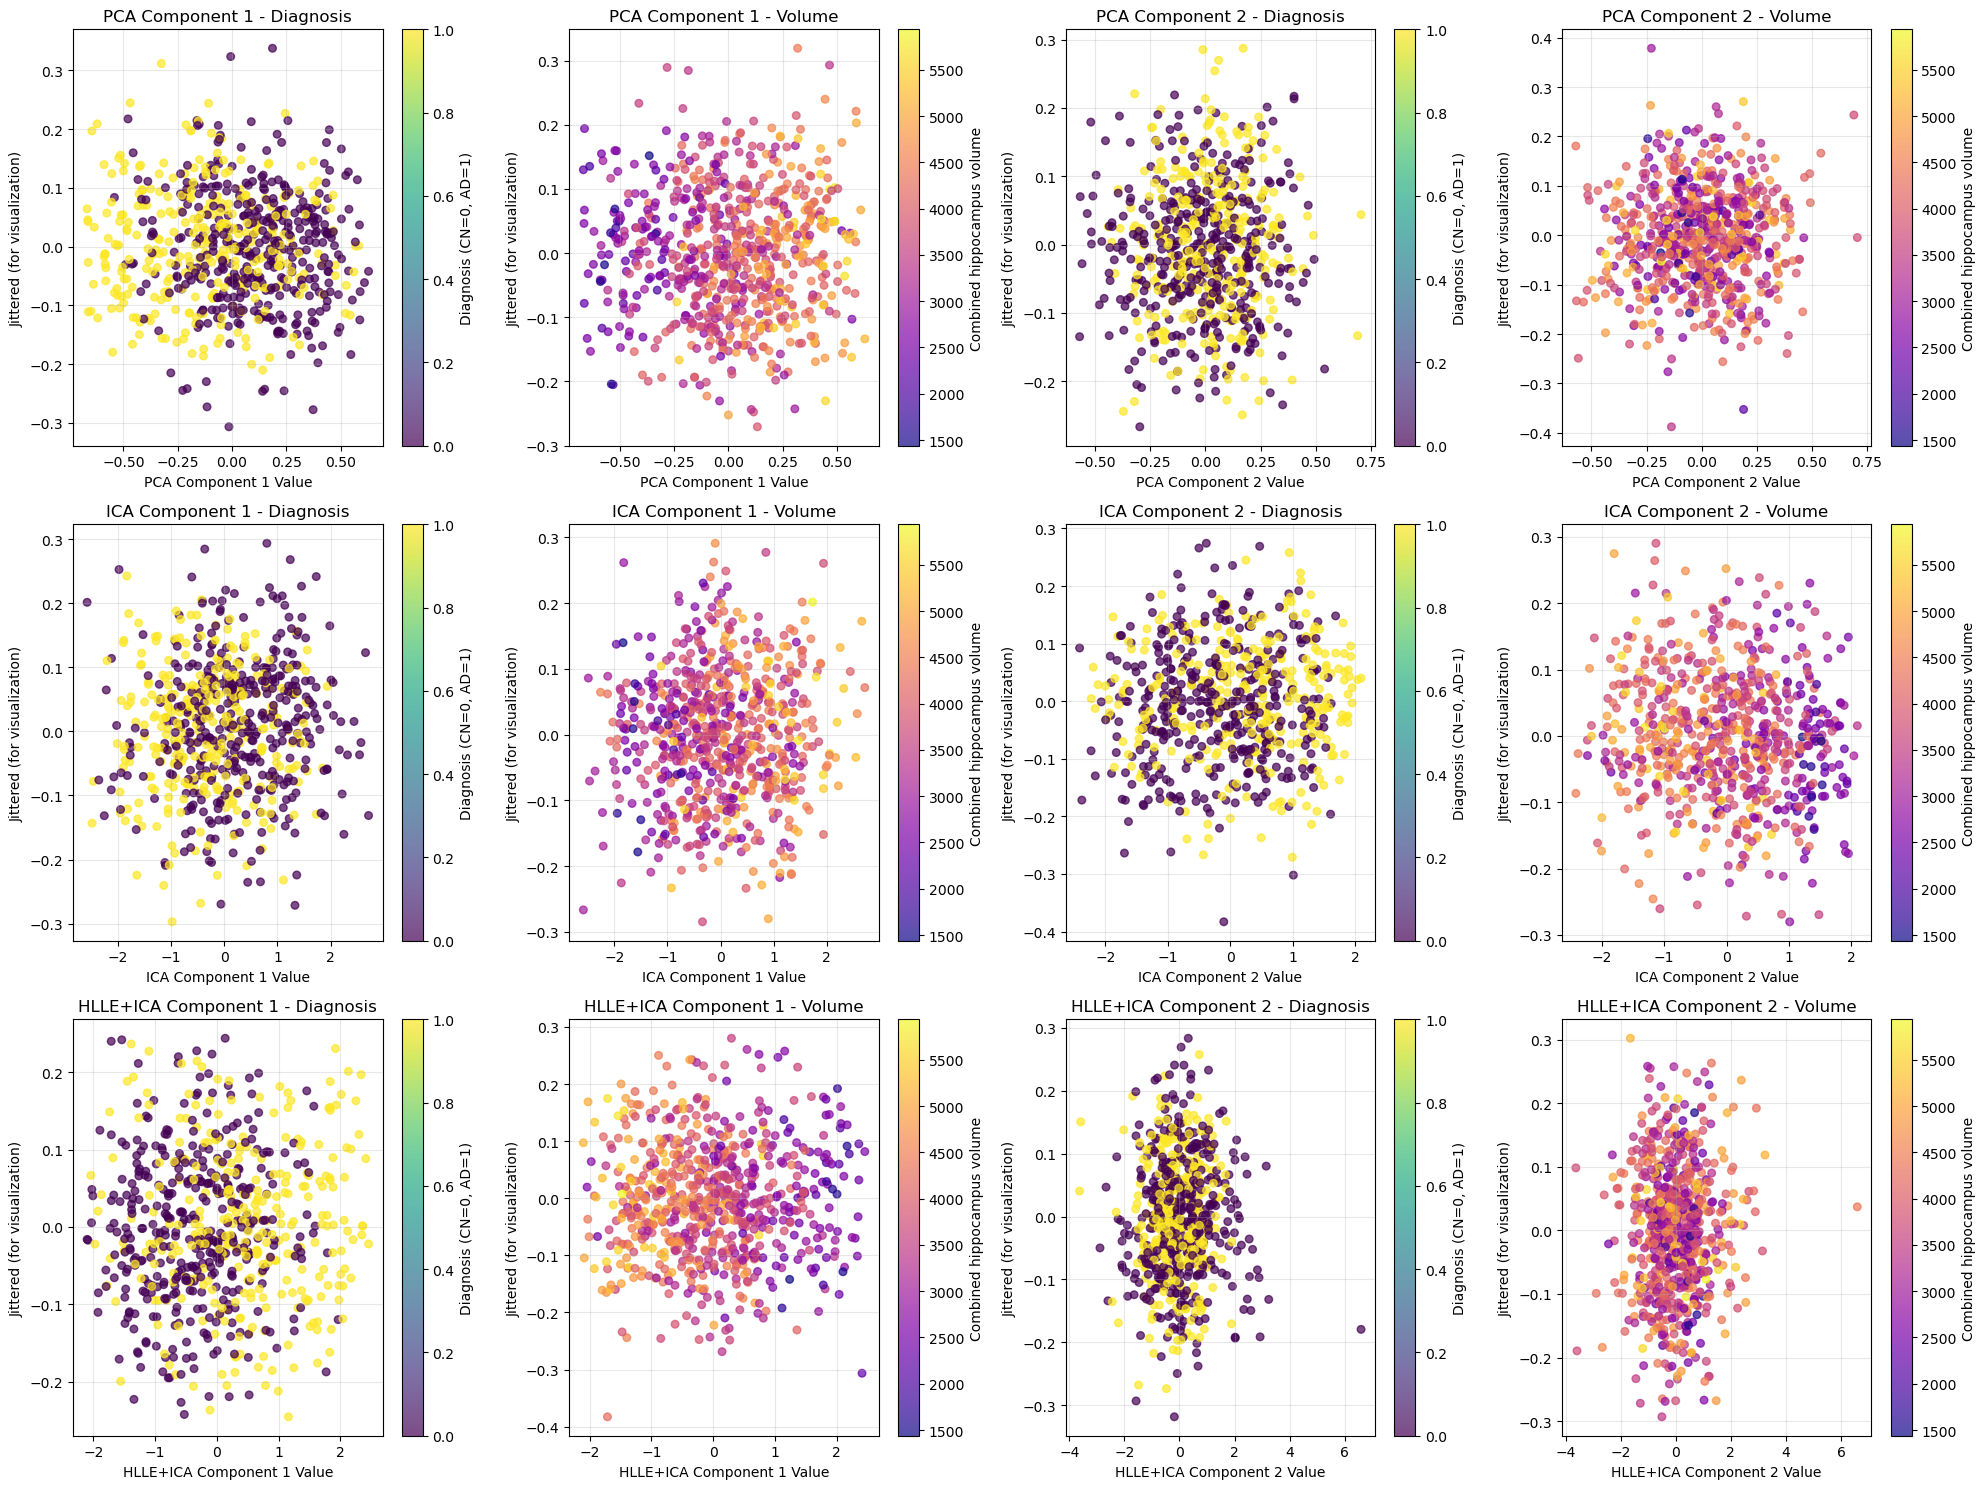

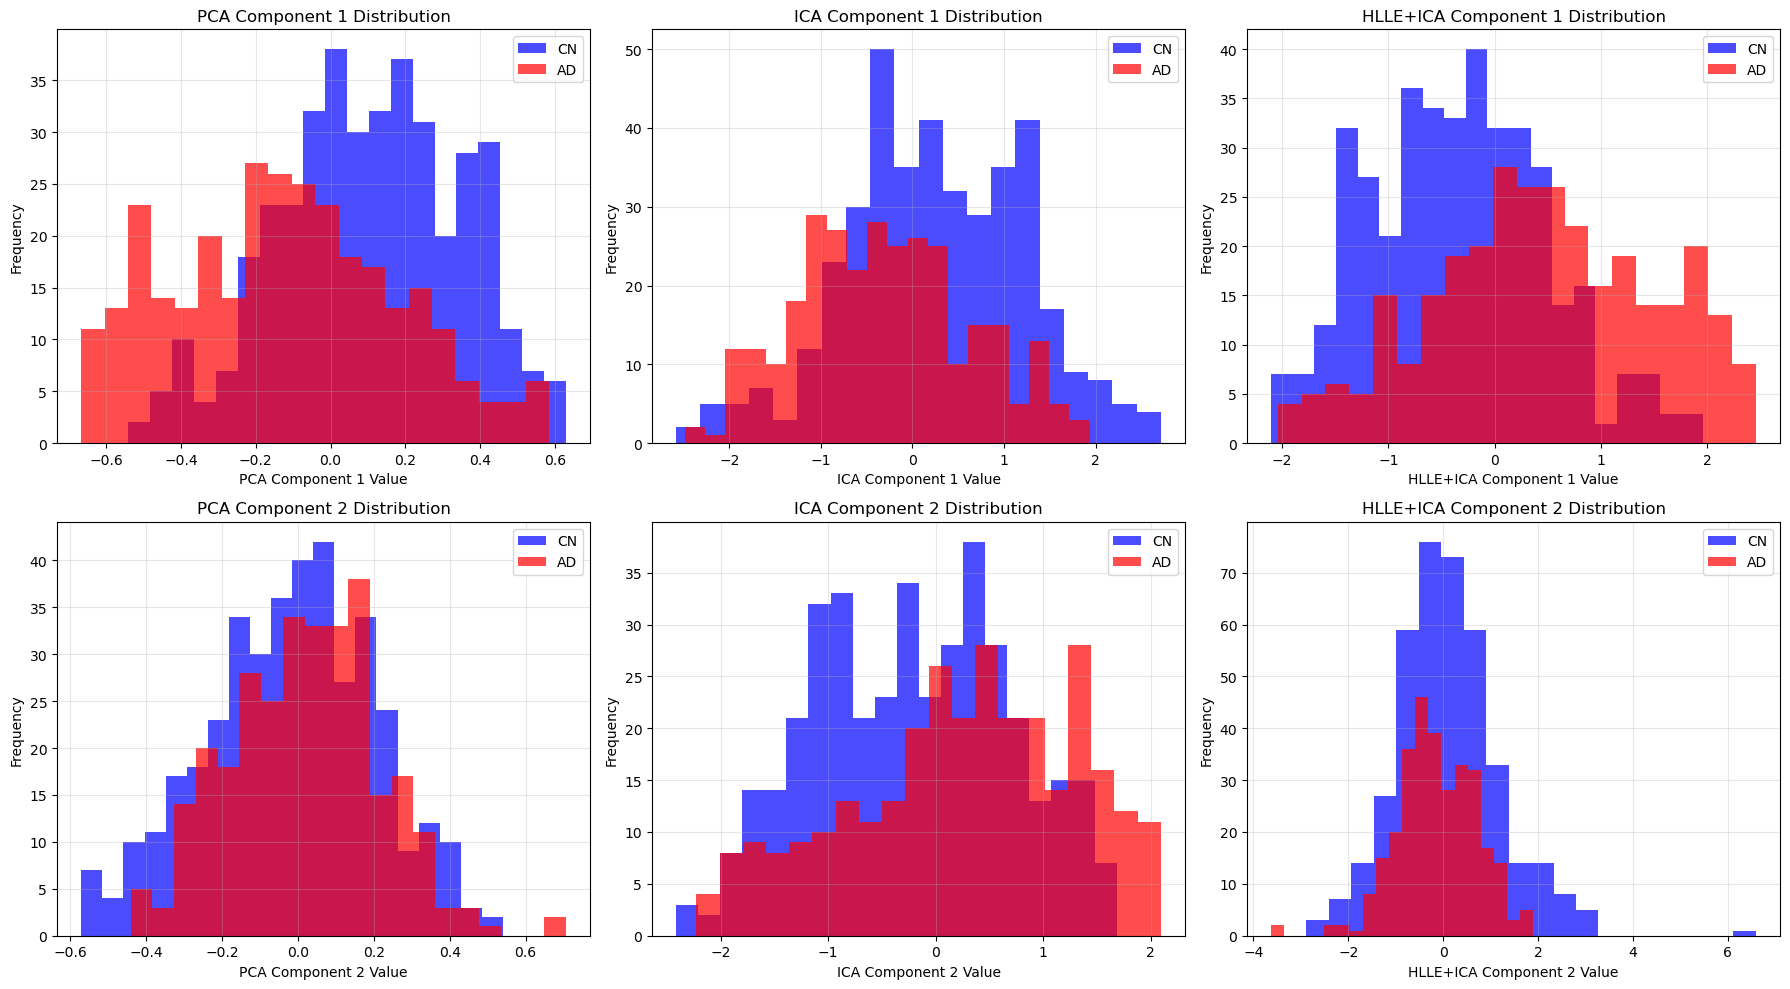

In [29]:
# 9. Project individual latent vectors onto learned components
print('Projecting individual latent vectors onto learned components...')

X_16d = latent_vectors.cpu().numpy()

individual_projections = {}

pca_components = pca.components_
pca_projections = X_16d @ pca_components.T
individual_projections['PCA'] = pca_projections

ica_components = ica.components_
ica_projections = X_16d @ ica_components.T
individual_projections['ICA'] = ica_projections

if best_Y_hlle_ica is not None:
    best_n_neighbors = best_params[0]
    hlle_for_projection = LocallyLinearEmbedding(n_neighbors=best_n_neighbors,
                                                 n_components=2,
                                                 method='hessian',
                                                 eigen_solver='dense')
    hlle_for_projection.fit(X)
    hlle_transformed = hlle_for_projection.transform(X_16d)
    ica_after_hlle = FastICA(n_components=2, random_state=42)
    hlle_train_transformed = hlle_for_projection.transform(X)
    ica_after_hlle.fit(hlle_train_transformed)
    hlle_ica_projections = ica_after_hlle.transform(hlle_transformed)
    individual_projections['HLLE+ICA'] = hlle_ica_projections
else:
    individual_projections['HLLE+ICA'] = None

print('Projection shapes:')
for method, proj in individual_projections.items():
    if proj is not None:
        print(f'{method}: {proj.shape}')

# 10. Visualize projections of first two components against labels
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

methods = ['PCA', 'ICA', 'HLLE+ICA']
for i, method in enumerate(methods):
    if individual_projections[method] is None:
        for j in range(4):
            axes[i, j].text(0.5, 0.5, f'{method}\nFailed', ha='center', va='center')
        continue

    projections = individual_projections[method]

    jittered_y1 = np.random.normal(0, 0.1, len(projections))
    scatter1 = axes[i, 0].scatter(projections[:, 0], jittered_y1, c=diagnosis,
                                 cmap='viridis', alpha=0.7, s=30)
    axes[i, 0].set_xlabel(f'{method} Component 1 Value')
    axes[i, 0].set_ylabel('Jittered (for visualization)')
    axes[i, 0].set_title(f'{method} Component 1 - Diagnosis')
    axes[i, 0].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[i, 0], label='Diagnosis (CN=0, AD=1)')

    vol_mask = np.isfinite(volume)
    jittered_y2 = np.random.normal(0, 0.1, np.sum(vol_mask))
    scatter2 = axes[i, 1].scatter(projections[vol_mask, 0], jittered_y2, c=volume[vol_mask],
                                 cmap='plasma', alpha=0.7, s=30)
    axes[i, 1].set_xlabel(f'{method} Component 1 Value')
    axes[i, 1].set_ylabel('Jittered (for visualization)')
    axes[i, 1].set_title(f'{method} Component 1 - Volume')
    axes[i, 1].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[i, 1], label='Combined hippocampus volume')

    if projections.shape[1] > 1:
        jittered_y3 = np.random.normal(0, 0.1, len(projections))
        scatter3 = axes[i, 2].scatter(projections[:, 1], jittered_y3, c=diagnosis,
                                     cmap='viridis', alpha=0.7, s=30)
        axes[i, 2].set_xlabel(f'{method} Component 2 Value')
        axes[i, 2].set_ylabel('Jittered (for visualization)')
        axes[i, 2].set_title(f'{method} Component 2 - Diagnosis')
        axes[i, 2].grid(True, alpha=0.3)
        plt.colorbar(scatter3, ax=axes[i, 2], label='Diagnosis (CN=0, AD=1)')

        jittered_y4 = np.random.normal(0, 0.1, np.sum(vol_mask))
        scatter4 = axes[i, 3].scatter(projections[vol_mask, 1], jittered_y4, c=volume[vol_mask],
                                     cmap='plasma', alpha=0.7, s=30)
        axes[i, 3].set_xlabel(f'{method} Component 2 Value')
        axes[i, 3].set_ylabel('Jittered (for visualization)')
        axes[i, 3].set_title(f'{method} Component 2 - Volume')
        axes[i, 3].grid(True, alpha=0.3)
        plt.colorbar(scatter4, ax=axes[i, 3], label='Combined hippocampus volume')
    else:
        axes[i, 2].text(0.5, 0.5, 'Only 1\nComponent', ha='center', va='center')
        axes[i, 3].text(0.5, 0.5, 'Only 1\nComponent', ha='center', va='center')

plt.tight_layout()
plt.savefig('component_projections_vs_labels_both_components.png', dpi=300, bbox_inches='tight')
plt.show()

# 13. Enhanced histogram visualization - both components
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, method in enumerate(methods):
    if individual_projections[method] is None:
        axes[0, i].text(0.5, 0.5, f'{method}\nFailed', ha='center', va='center')
        axes[1, i].text(0.5, 0.5, f'{method}\nFailed', ha='center', va='center')
        continue

    projections = individual_projections[method]
    cn_mask = diagnosis == 0
    ad_mask = diagnosis == 1

    first_component = projections[:, 0]
    axes[0, i].hist(first_component[cn_mask], alpha=0.7, label='CN', bins=20, color='blue')
    axes[0, i].hist(first_component[ad_mask], alpha=0.7, label='AD', bins=20, color='red')
    axes[0, i].set_xlabel(f'{method} Component 1 Value')
    axes[0, i].set_ylabel('Frequency')
    axes[0, i].set_title(f'{method} Component 1 Distribution')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

    if projections.shape[1] > 1:
        second_component = projections[:, 1]
        axes[1, i].hist(second_component[cn_mask], alpha=0.7, label='CN', bins=20, color='blue')
        axes[1, i].hist(second_component[ad_mask], alpha=0.7, label='AD', bins=20, color='red')
        axes[1, i].set_xlabel(f'{method} Component 2 Value')
        axes[1, i].set_ylabel('Frequency')
        axes[1, i].set_title(f'{method} Component 2 Distribution')
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)
    else:
        axes[1, i].text(0.5, 0.5, 'Only 1\nComponent', ha='center', va='center')

plt.tight_layout()
plt.savefig('component_distributions_both_components.png', dpi=300, bbox_inches='tight')
plt.show()


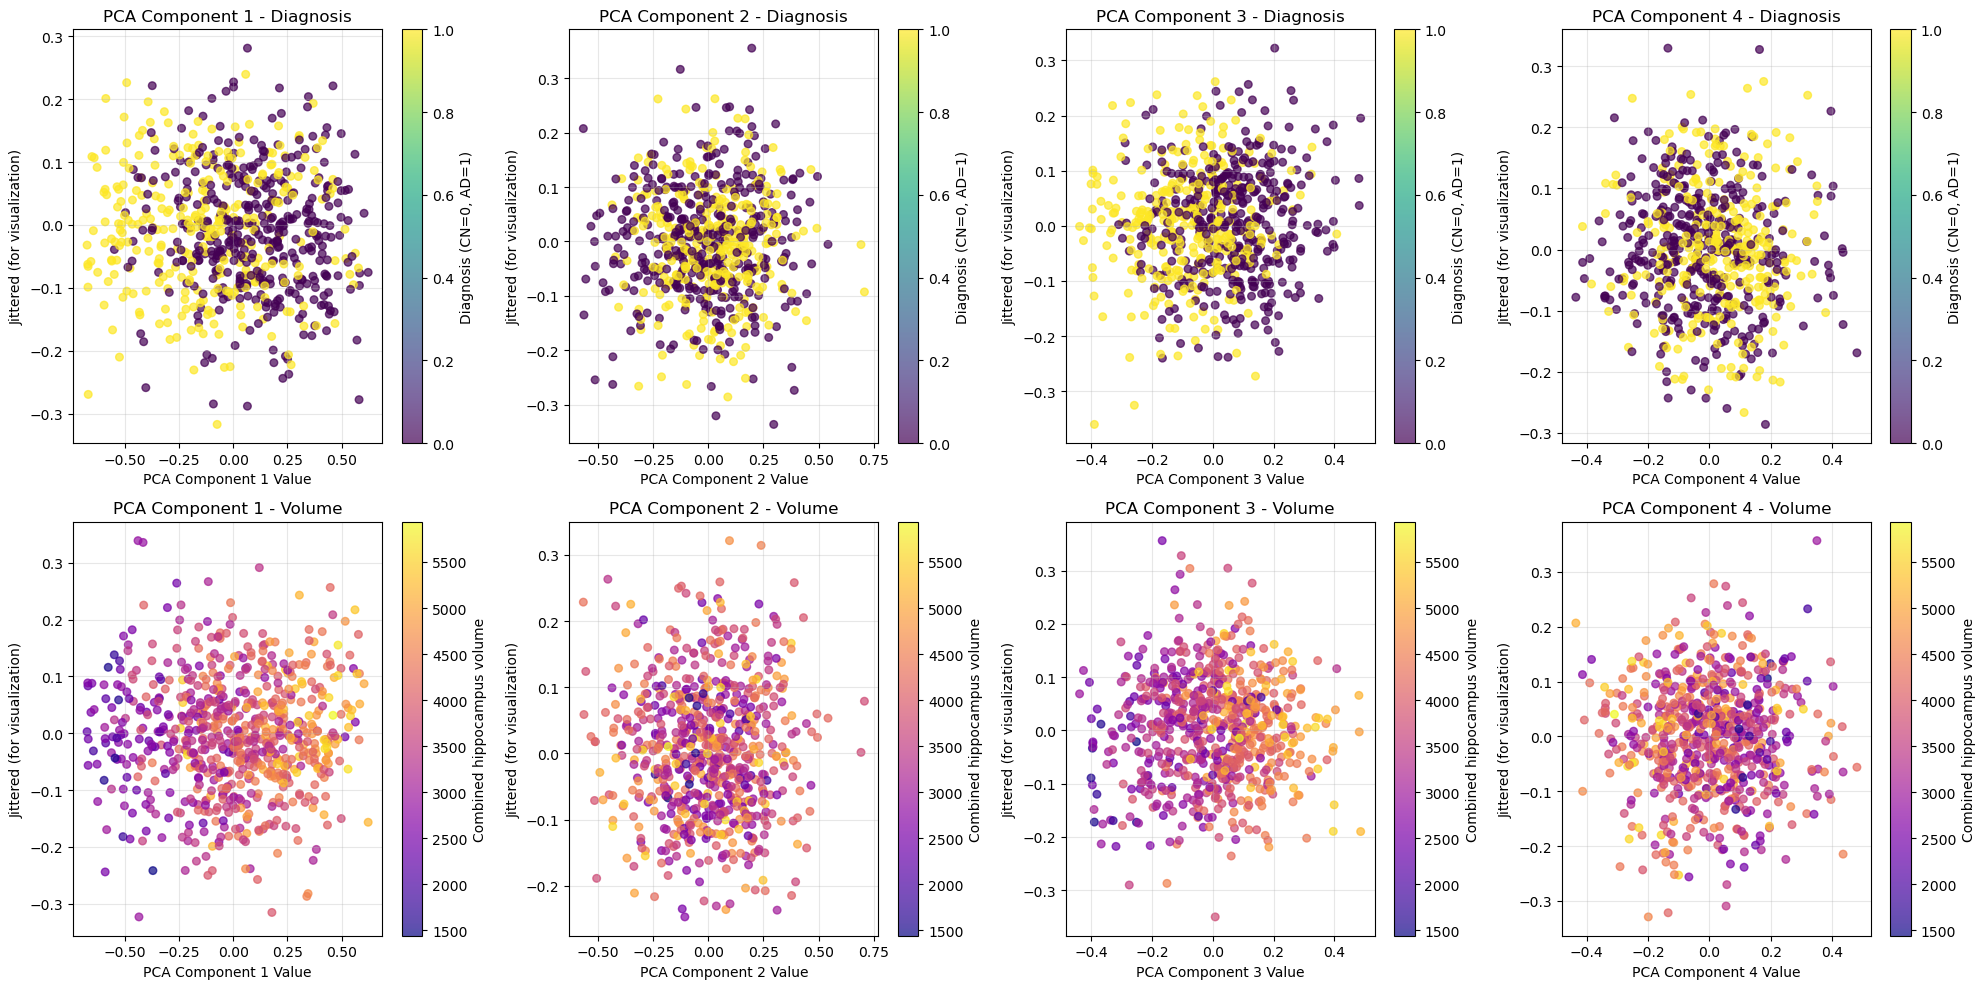

In [30]:
# Plot all 4 PCA components for diagnosis and volume
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

pca_results = results['PCA']

for i in range(4):
    jittered_y = np.random.normal(0, 0.1, len(pca_results))
    scatter = axes[0, i].scatter(pca_results[:, i], jittered_y, c=diagnosis,
                                cmap='viridis', alpha=0.7, s=30)
    axes[0, i].set_xlabel(f'PCA Component {i+1} Value')
    axes[0, i].set_ylabel('Jittered (for visualization)')
    axes[0, i].set_title(f'PCA Component {i+1} - Diagnosis')
    axes[0, i].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0, i], label='Diagnosis (CN=0, AD=1)')

for i in range(4):
    mask = np.isfinite(volume)
    jittered_y = np.random.normal(0, 0.1, np.sum(mask))
    scatter = axes[1, i].scatter(pca_results[mask, i], jittered_y, c=volume[mask],
                                cmap='plasma', alpha=0.7, s=30)
    axes[1, i].set_xlabel(f'PCA Component {i+1} Value')
    axes[1, i].set_ylabel('Jittered (for visualization)')
    axes[1, i].set_title(f'PCA Component {i+1} - Volume')
    axes[1, i].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[1, i], label='Combined hippocampus volume')

plt.tight_layout()
plt.show()



Analyzing volume encoding across all latent dimensions:
Latent dim 1: volume correlation = -0.0381
Latent dim 2: volume correlation = -0.0218
Latent dim 3: volume correlation = -0.1231
Latent dim 4: volume correlation = -0.0533
Latent dim 5: volume correlation = -0.0049
Latent dim 6: volume correlation = -0.0881
Latent dim 7: volume correlation = -0.0035
Latent dim 8: volume correlation = 0.0088
Latent dim 9: volume correlation = 0.0496
Latent dim 10: volume correlation = 0.0246
Latent dim 11: volume correlation = -0.0243
Latent dim 12: volume correlation = -0.0189
Latent dim 13: volume correlation = 0.5111
Latent dim 14: volume correlation = 0.0253
Latent dim 15: volume correlation = 0.1538
Latent dim 16: volume correlation = 0.0044
Latent dim 17: volume correlation = 0.0655
Latent dim 18: volume correlation = -0.0010
Latent dim 19: volume correlation = -0.0320
Latent dim 20: volume correlation = 0.0189
Latent dim 21: volume correlation = -0.2257
Latent dim 22: volume correlation = 0

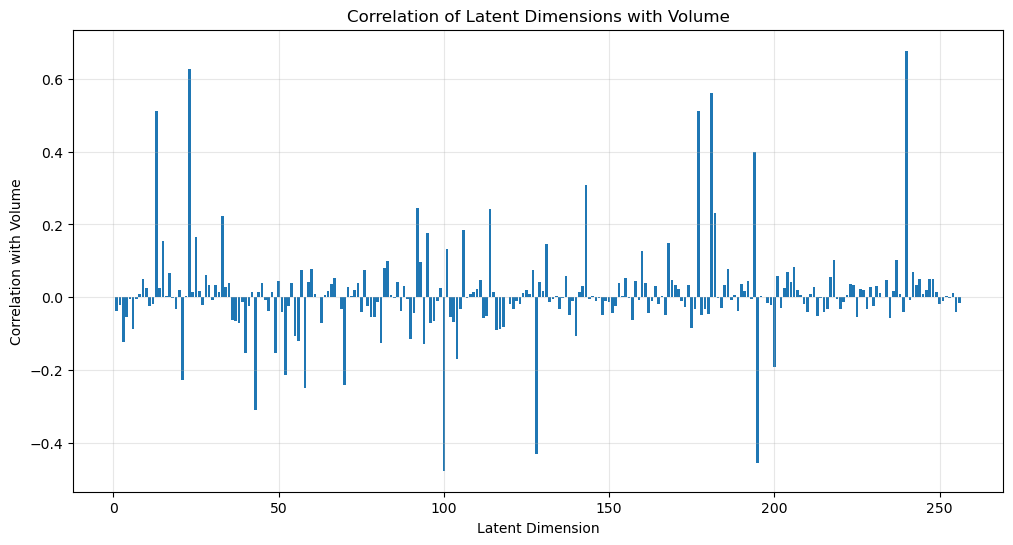

In [15]:
# Test if volume information is distributed across all dimensions
print('\nAnalyzing volume encoding across all latent dimensions:')

latent_volume_correlations = []
mask = np.isfinite(volume)
for dim in range(X.shape[1]):
    if np.any(mask):
        corr = np.corrcoef(X[mask, dim], volume[mask])[0, 1]
    else:
        corr = float('nan')
    latent_volume_correlations.append(corr)
    print(f'Latent dim {dim+1}: volume correlation = {corr:.4f}')

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

if np.any(mask):
    lr = LinearRegression()
    lr.fit(X[mask], volume[mask])
    predicted_volumes = lr.predict(X[mask])
    r2 = r2_score(volume[mask], predicted_volumes)
    quality = 'well' if r2 > 0.7 else 'poorly'
    print(f'\nLinear regression R² for predicting volume: {r2:.4f}')
    print(f'This suggests volume information is {quality} encoded in the full latent space')
else:
    print('No finite volume values for linear regression.')

plt.figure(figsize=(12, 6))
plt.bar(range(1, len(latent_volume_correlations) + 1), latent_volume_correlations)
plt.xlabel('Latent Dimension')
plt.ylabel('Correlation with Volume')
plt.title('Correlation of Latent Dimensions with Volume')
plt.grid(True, alpha=0.3)
plt.show()


In [16]:
# Add this cell to your notebook
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import seaborn as sns

# Unsupervised Clustering Analysis
print("=== UNSUPERVISED CLUSTERING ANALYSIS ===")

# Use your original 16D latent vectors
X_clustering = X.copy()  # Your original 16D latent vectors

# Standardize the data for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# Dictionary to store clustering results
clustering_results = {}
cluster_metrics = {}

# 1. K-Means Clustering with different numbers of clusters
print("\n1. K-Means Clustering:")
k_range = range(2, 11)  # Try 2 to 10 clusters
kmeans_scores = {'silhouette': [], 'calinski': [], 'davies_bouldin': []}

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Calculate clustering metrics
    sil_score = silhouette_score(X_scaled, cluster_labels)
    cal_score = calinski_harabasz_score(X_scaled, cluster_labels)
    db_score = davies_bouldin_score(X_scaled, cluster_labels)
    
    kmeans_scores['silhouette'].append(sil_score)
    kmeans_scores['calinski'].append(cal_score)
    kmeans_scores['davies_bouldin'].append(db_score)
    
    print(f"K={k}: Silhouette={sil_score:.3f}, Calinski-Harabasz={cal_score:.1f}, Davies-Bouldin={db_score:.3f}")
    
    if k == 3:  # Store 3-cluster result as example
        clustering_results['KMeans_3'] = cluster_labels
        cluster_metrics['KMeans_3'] = {'silhouette': sil_score, 'calinski': cal_score, 'davies_bouldin': db_score}

# Find optimal K for K-means
best_k_sil = k_range[np.argmax(kmeans_scores['silhouette'])]
best_k_cal = k_range[np.argmax(kmeans_scores['calinski'])]
best_k_db = k_range[np.argmin(kmeans_scores['davies_bouldin'])]

print(f"\nOptimal K by Silhouette: {best_k_sil}")
print(f"Optimal K by Calinski-Harabasz: {best_k_cal}")
print(f"Optimal K by Davies-Bouldin: {best_k_db}")

# Run K-means with the best K (by silhouette score)
best_kmeans = KMeans(n_clusters=best_k_sil, random_state=42, n_init=10)
best_kmeans_labels = best_kmeans.fit_predict(X_scaled)
clustering_results['KMeans_Best'] = best_kmeans_labels

=== UNSUPERVISED CLUSTERING ANALYSIS ===

1. K-Means Clustering:
K=2: Silhouette=0.018, Calinski-Harabasz=12.0, Davies-Bouldin=7.547
K=3: Silhouette=0.009, Calinski-Harabasz=10.7, Davies-Bouldin=6.614
K=4: Silhouette=0.012, Calinski-Harabasz=9.3, Davies-Bouldin=6.349
K=5: Silhouette=0.011, Calinski-Harabasz=8.2, Davies-Bouldin=6.180
K=6: Silhouette=0.013, Calinski-Harabasz=7.6, Davies-Bouldin=5.914
K=7: Silhouette=0.006, Calinski-Harabasz=7.2, Davies-Bouldin=5.660
K=8: Silhouette=0.009, Calinski-Harabasz=6.9, Davies-Bouldin=4.846
K=9: Silhouette=0.014, Calinski-Harabasz=6.6, Davies-Bouldin=5.112
K=10: Silhouette=0.015, Calinski-Harabasz=6.5, Davies-Bouldin=4.990

Optimal K by Silhouette: 2
Optimal K by Calinski-Harabasz: 2
Optimal K by Davies-Bouldin: 8


In [17]:
# 2. Gaussian Mixture Model
print("\n2. Gaussian Mixture Model:")
gmm_scores = {'silhouette': [], 'aic': [], 'bic': []}

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    cluster_labels = gmm.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, cluster_labels)
    aic_score = gmm.aic(X_scaled)
    bic_score = gmm.bic(X_scaled)
    
    gmm_scores['silhouette'].append(sil_score)
    gmm_scores['aic'].append(aic_score)
    gmm_scores['bic'].append(bic_score)
    
    print(f"K={k}: Silhouette={sil_score:.3f}, AIC={aic_score:.1f}, BIC={bic_score:.1f}")

# Find optimal K for GMM
best_k_gmm = k_range[np.argmax(gmm_scores['silhouette'])]
best_gmm = GaussianMixture(n_components=best_k_gmm, random_state=42)
best_gmm_labels = best_gmm.fit_predict(X_scaled)
clustering_results['GMM_Best'] = best_gmm_labels

# 3. DBSCAN Clustering
print("\n3. DBSCAN Clustering:")
# Try different eps values
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    cluster_labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)
    
    if n_clusters > 1:  # Only calculate if we have valid clusters
        sil_score = silhouette_score(X_scaled, cluster_labels)
        dbscan_results.append((eps, n_clusters, n_noise, sil_score))
        print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points, Silhouette={sil_score:.3f}")
    else:
        print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points (invalid)")

# Select best DBSCAN result
if dbscan_results:
    best_dbscan = max(dbscan_results, key=lambda x: x[3])  # Best by silhouette score
    best_eps = best_dbscan[0]
    
    dbscan_final = DBSCAN(eps=best_eps, min_samples=5)
    dbscan_labels = dbscan_final.fit_predict(X_scaled)
    clustering_results['DBSCAN_Best'] = dbscan_labels
    print(f"Best DBSCAN: eps={best_eps}, silhouette={best_dbscan[3]:.3f}")


2. Gaussian Mixture Model:
K=2: Silhouette=0.028, AIC=304480.3, BIC=605859.7
K=3: Silhouette=0.012, AIC=182334.3, BIC=634405.7
K=4: Silhouette=0.015, AIC=309794.5, BIC=912557.9
K=5: Silhouette=0.016, AIC=256866.5, BIC=1010321.9
K=6: Silhouette=0.017, AIC=-94350.4, BIC=809796.9


K=7: Silhouette=0.010, AIC=-183125.4, BIC=871713.9
K=8: Silhouette=0.012, AIC=-274785.5, BIC=930745.8
K=9: Silhouette=0.010, AIC=-417711.4, BIC=938511.8
K=10: Silhouette=0.004, AIC=-440663.7, BIC=1066251.5

3. DBSCAN Clustering:
eps=0.3: 0 clusters, 696 noise points (invalid)
eps=0.5: 0 clusters, 696 noise points (invalid)
eps=0.7: 0 clusters, 696 noise points (invalid)
eps=1.0: 0 clusters, 696 noise points (invalid)
eps=1.5: 0 clusters, 696 noise points (invalid)
eps=2.0: 0 clusters, 696 noise points (invalid)


In [19]:
# 4. Hierarchical Clustering
print("\n4. Hierarchical Clustering:")
hier_linkages = ['ward', 'complete', 'average']
hier_results = {}

for linkage in hier_linkages:
    for k in [2, 3, 4, 5]:
        hierarchical = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        cluster_labels = hierarchical.fit_predict(X_scaled)
        
        sil_score = silhouette_score(X_scaled, cluster_labels)
        hier_results[f'{linkage}_{k}'] = (cluster_labels, sil_score)
        print(f"Linkage={linkage}, K={k}: Silhouette={sil_score:.3f}")

# Find best hierarchical clustering
best_hier = max(hier_results.items(), key=lambda x: x[1][1])
clustering_results['Hierarchical_Best'] = best_hier[1][0]

# 5. Spectral Clustering
print("\n5. Spectral Clustering:")
spectral_results = {}

for k in [2, 3, 4, 5]:
    spectral = SpectralClustering(n_clusters=k, random_state=42)
    cluster_labels = spectral.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, cluster_labels)
    spectral_results[k] = (cluster_labels, sil_score)
    print(f"K={k}: Silhouette={sil_score:.3f}")

# Find best spectral clustering
best_spectral = max(spectral_results.items(), key=lambda x: x[1][1])
clustering_results['Spectral_Best'] = best_spectral[1][0]


4. Hierarchical Clustering:
Linkage=ward, K=2: Silhouette=0.024
Linkage=ward, K=3: Silhouette=0.019
Linkage=ward, K=4: Silhouette=0.017
Linkage=ward, K=5: Silhouette=0.014
Linkage=complete, K=2: Silhouette=0.033
Linkage=complete, K=3: Silhouette=0.015
Linkage=complete, K=4: Silhouette=0.010
Linkage=complete, K=5: Silhouette=0.010
Linkage=average, K=2: Silhouette=0.087
Linkage=average, K=3: Silhouette=0.059
Linkage=average, K=4: Silhouette=0.044
Linkage=average, K=5: Silhouette=0.039

5. Spectral Clustering:
K=2: Silhouette=0.086
K=3: Silhouette=0.067
K=4: Silhouette=0.032
K=5: Silhouette=0.022


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 23 with accuracies 
[1.23030160e-14 1.66773453e-06 4.30908452e-06 1.56384535e-05
 6.72788960e-06 6.43127000e-06]
not reaching the requested tolerance 1.0371208190917969e-05.
Use iteration 23 instead with accuracy 
5.7957386970008575e-06.

  _, diffusion_map = lobpcg(
/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited postprocessing with accuracies 
[1.42178378e-14 1.66773486e-06 4.30908403e-06 1.56384535e-05
 6.72788988e-06 6.43126999e-06]
not reaching the requested tolerance 1.0371208190917969e-05.
  _, diffusion_map = lobpcg(



6. Visualization of Clustering Results:


UMAP failed (check_array() got an unexpected keyword argument 'ensure_all_finite'); using t-SNE for visualization


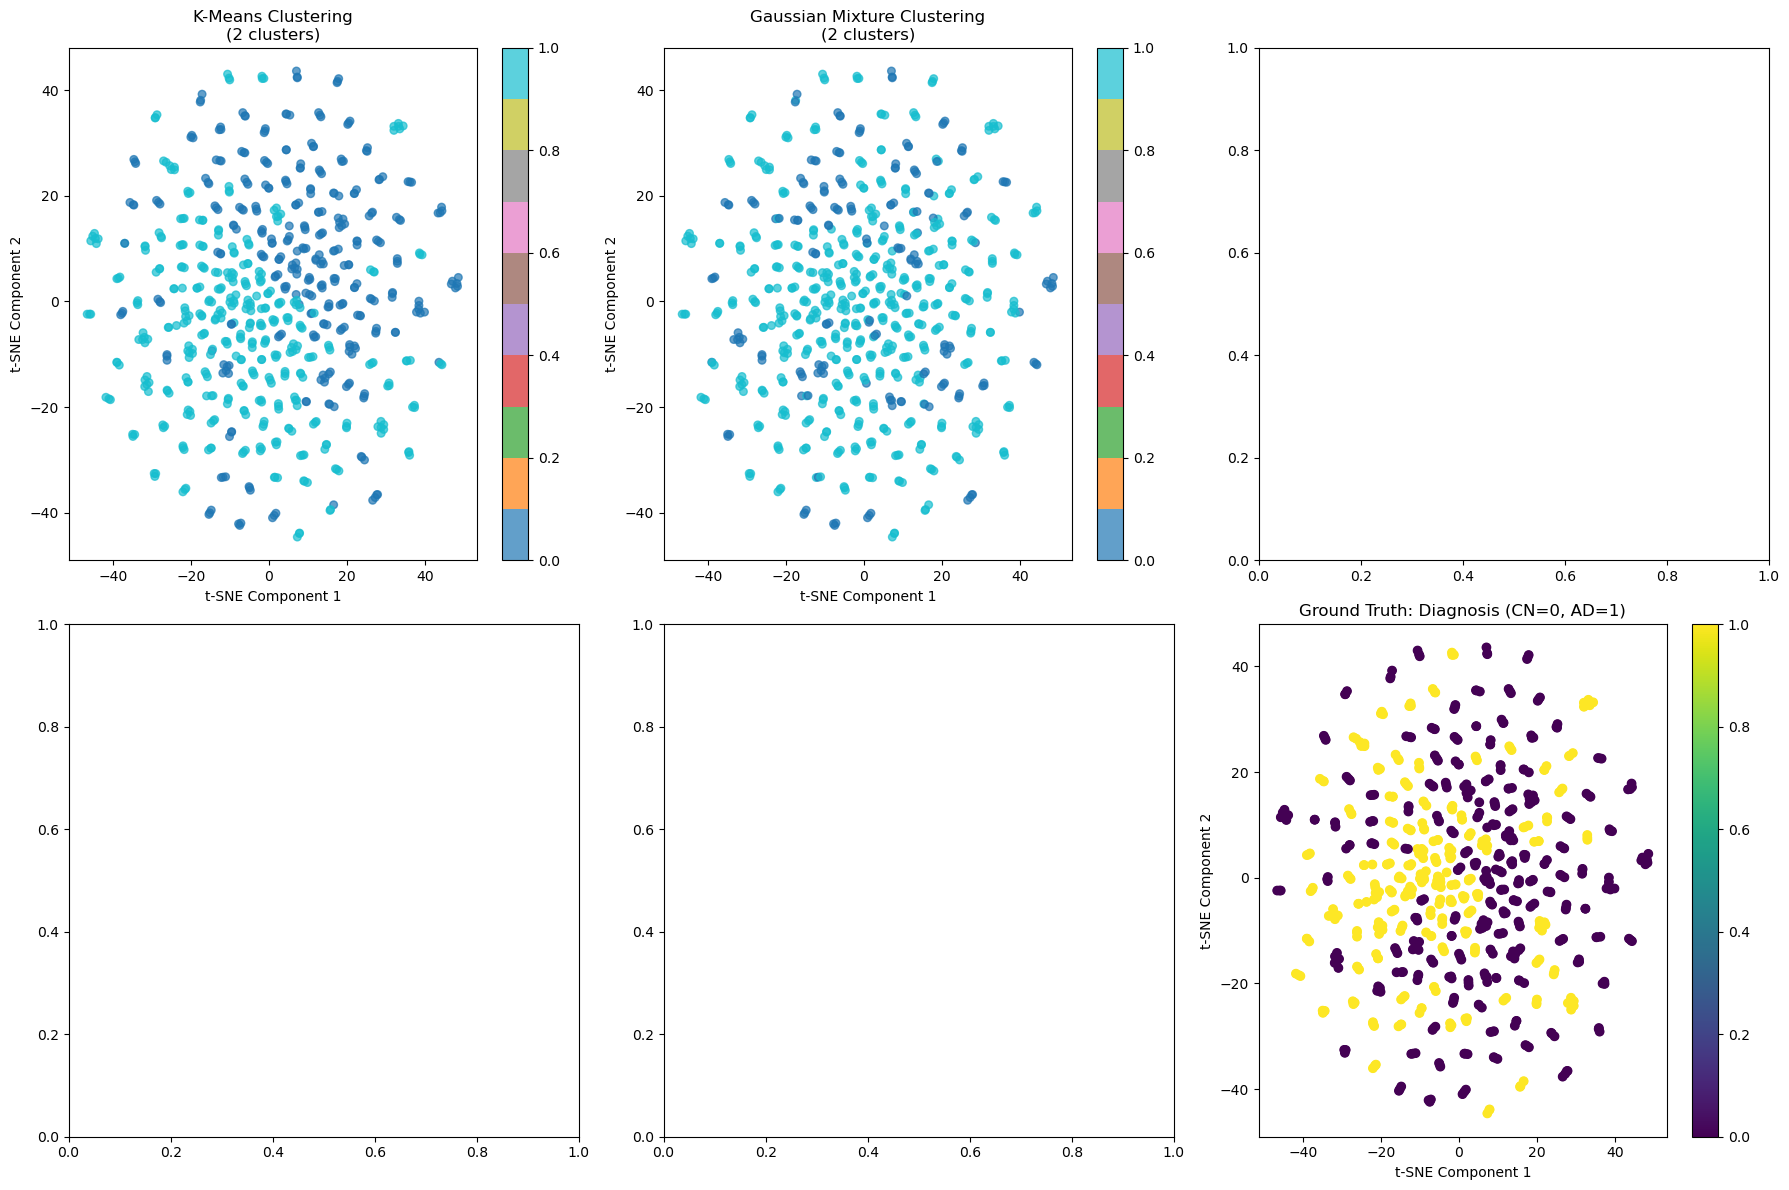

In [18]:
# 6. Visualize clustering results using dimensionality reduction
print('\n6. Visualization of Clustering Results:')

embedding_label = 'UMAP'
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)
    print('Using UMAP for visualization')
except Exception as e:
    from sklearn.manifold import TSNE
    embedding_label = 't-SNE'
    print(f'UMAP failed ({e}); using t-SNE for visualization')
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_umap = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

methods = ['KMeans_Best', 'GMM_Best', 'DBSCAN_Best', 'Hierarchical_Best', 'Spectral_Best']
method_names = ['K-Means', 'Gaussian Mixture', 'DBSCAN', 'Hierarchical', 'Spectral']

for i, (method, name) in enumerate(zip(methods, method_names)):
    if method in clustering_results:
        labels = clustering_results[method]
        scatter = axes[i].scatter(X_umap[:, 0], X_umap[:, 1], c=labels,
                                 cmap='tab10', alpha=0.7, s=30)
        axes[i].set_title(f'{name} Clustering\n({len(set(labels))} clusters)')
        axes[i].set_xlabel(f'{embedding_label} Component 1')
        axes[i].set_ylabel(f'{embedding_label} Component 2')
        plt.colorbar(scatter, ax=axes[i])

axes[5].scatter(X_umap[:, 0], X_umap[:, 1], c=diagnosis, cmap='viridis', alpha=0.7, s=30)
axes[5].set_title('Ground Truth: Diagnosis (CN=0, AD=1)')
axes[5].set_xlabel(f'{embedding_label} Component 1')
axes[5].set_ylabel(f'{embedding_label} Component 2')
plt.colorbar(axes[5].scatter(X_umap[:, 0], X_umap[:, 1], c=diagnosis, cmap='viridis'), ax=axes[5])

plt.tight_layout()
plt.savefig('clustering_results_visualization.png', dpi=300, bbox_inches='tight')
plt.show()


In [19]:
# 7. Analyze cluster characteristics
print('\n7. Cluster Analysis:')

best_labels = clustering_results['KMeans_Best']
unique_clusters = sorted(set(best_labels))

print(f'\nAnalyzing K-Means clustering with {len(unique_clusters)} clusters:')

cluster_analysis = {}
for cluster_id in unique_clusters:
    cluster_mask = best_labels == cluster_id

    cluster_diag_ratio = np.mean(diagnosis[cluster_mask] == 1) if np.any(cluster_mask) else float('nan')
    cluster_vol_mean = np.mean(volume[cluster_mask]) if np.any(cluster_mask) else float('nan')
    cluster_vol_std = np.std(volume[cluster_mask]) if np.any(cluster_mask) else float('nan')
    cluster_size = np.sum(cluster_mask)

    cluster_analysis[cluster_id] = {
        'size': cluster_size,
        'ad_ratio': cluster_diag_ratio,
        'volume_mean': cluster_vol_mean,
        'volume_std': cluster_vol_std,
    }

    print(f'Cluster {cluster_id}:')
    print(f'  Size: {cluster_size} samples')
    print(f'  AD ratio: {cluster_diag_ratio:.3f}')
    print(f'  Volume mean±std: {cluster_vol_mean:.3f}±{cluster_vol_std:.3f}')

# 8. Create new labels from clustering
print('\n8. Creating Training Labels from Clusters:')

cluster_labels_for_training = best_labels
np.save('unsupervised_cluster_labels.npy', cluster_labels_for_training)
print("Saved cluster labels to 'unsupervised_cluster_labels.npy'")
print(f'Shape: {cluster_labels_for_training.shape}')
print(f'Unique clusters: {sorted(set(cluster_labels_for_training))}')



7. Cluster Analysis:

Analyzing K-Means clustering with 2 clusters:
Cluster 0:
  Size: 320 samples
  AD ratio: 0.297
  Volume mean±std: 4162.537±703.481
Cluster 1:
  Size: 376 samples
  AD ratio: 0.553
  Volume mean±std: 3442.448±850.353

8. Creating Training Labels from Clusters:
Saved cluster labels to 'unsupervised_cluster_labels.npy'
Shape: (696,)
Unique clusters: [0, 1]


In [20]:
# 9. Map cluster IDs to diagnosis labels (CN/AD)
print('\n9. Cluster-to-Diagnosis Mapping:')

def summarize_cluster_labels(labels, diagnosis):
    mapping = {}
    unique_clusters = sorted(set(labels))
    for cluster_id in unique_clusters:
        mask = labels == cluster_id
        cn_count = int((diagnosis[mask] == 0).sum())
        ad_count = int((diagnosis[mask] == 1).sum())
        total = cn_count + ad_count
        if total == 0:
            majority_label = 'N/A'
            majority_ratio = float('nan')
        else:
            majority_label = 'AD' if ad_count >= cn_count else 'CN'
            majority_ratio = max(ad_count, cn_count) / total
        mapping[cluster_id] = {
            'size': total,
            'cn': cn_count,
            'ad': ad_count,
            'majority_label': majority_label,
            'majority_ratio': majority_ratio,
        }
        print(f'  Cluster {cluster_id}: CN={cn_count}, AD={ad_count}, '
              f'majority={majority_label} ({majority_ratio:.2%})')

    total_correct = sum(max(stats['cn'], stats['ad']) for stats in mapping.values())
    total = sum(stats['size'] for stats in mapping.values())
    if total > 0:
        print(f'  Purity (majority-vote accuracy): {total_correct / total:.3%}')
    return mapping

# Evaluate all available clustering methods
for method_name, labels in clustering_results.items():
    print(f'\nMethod: {method_name}')
    summarize_cluster_labels(labels, diagnosis)



9. Cluster-to-Diagnosis Mapping:

Method: KMeans_3
  Cluster 0: CN=81, AD=103, majority=AD (55.98%)
  Cluster 1: CN=186, AD=78, majority=CN (70.45%)
  Cluster 2: CN=126, AD=122, majority=CN (50.81%)
  Purity (majority-vote accuracy): 59.626%

Method: KMeans_Best
  Cluster 0: CN=225, AD=95, majority=CN (70.31%)
  Cluster 1: CN=168, AD=208, majority=AD (55.32%)
  Purity (majority-vote accuracy): 62.213%

Method: GMM_Best
  Cluster 0: CN=117, AD=63, majority=CN (65.00%)
  Cluster 1: CN=276, AD=240, majority=CN (53.49%)
  Purity (majority-vote accuracy): 56.466%
